# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
!git clone https://github.com/Tiendung3tzz/K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork.git

Cloning into 'K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 63 (delta 21), reused 29 (delta 16), pack-reused 16 (from 1)
Receiving objects: 100% (63/63), 11.76 MiB | 25.40 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [5]:
print(os.getcwd())
print(os.path.abspath(REPO_ROOT))
print(os.path.abspath(OUT_DIR))

/kaggle/working
/kaggle/working/K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork
/kaggle/working/K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork/submission_2A202602791


In [4]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

REPO_ROOT = os.path.abspath(REPO_ROOT)
OUT_DIR = os.path.abspath(OUT_DIR)
if not (os.path.isdir(os.path.join(REPO_ROOT, "data")) and os.path.isdir(os.path.join(REPO_ROOT, "scripts"))):
    search_dirs = [os.getcwd(), "/kaggle/working"]
    candidates = []
    for base in search_dirs:
        if os.path.isdir(base):
            candidates.extend([base] + [os.path.join(base, name) for name in os.listdir(base)])
    roots = [path for path in candidates if os.path.isdir(os.path.join(path, "data")) and os.path.isdir(os.path.join(path, "scripts"))]
    if not roots:
        raise FileNotFoundError("Không tìm thấy thư mục repo chứa data/ và scripts/")
    REPO_ROOT = roots[0]
    submissions = [os.path.join(REPO_ROOT, name) for name in os.listdir(REPO_ROOT) if name.startswith("submission_") and os.path.isdir(os.path.join(REPO_ROOT, name))]
    OUT_DIR = submissions[0] if submissions else os.path.join(REPO_ROOT, "submission_2A202602791")
CODE_DIR = os.path.join(OUT_DIR, "code")
if os.path.isdir(CODE_DIR) and CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else device.type
print(f"PyTorch {torch.__version__}; device={device} ({device_name})")
os.makedirs(os.path.join(OUT_DIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "results"), exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch 2.11.0+cu128; device=cuda (Tesla T4)


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [7]:
split_env = os.environ.copy()
split_env["PYTHONIOENCODING"] = "utf-8"
subprocess.run([sys.executable, os.path.join(REPO_ROOT, "scripts", "split_data.py")], cwd=REPO_ROOT, env=split_env, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=os.path.join(REPO_ROOT, "data", "processed"))
for name in ("X_tr", "y_tr", "X_val", "y_val", "X_eval", "y_eval"):
    print(name, tuple(data[name].shape), data[name].dtype, data[name].device)
majority = int(torch.bincount(data["y_tr"], minlength=7).argmax())
majority_acc = (data["y_val"] == majority).float().mean().item()
numeric_mean = data["X_tr"][:, :10].mean(dim=0).detach().cpu().numpy()
numeric_std = data["X_tr"][:, :10].std(dim=0, unbiased=False).detach().cpu().numpy()
print(f"majority class={majority}, val accuracy={majority_acc:.4f}")
print("train numeric mean:", np.round(numeric_mean, 4))
print("train numeric std :", np.round(numeric_std, 4))
assert data["X_tr"].shape == (371847, 54)
assert data["X_val"].shape == (92962, 54)
assert data["X_eval"].shape == (116203, 54)
assert data["y_tr"].shape == (371847,) and data["y_tr"].dtype == torch.int64
assert data["y_val"].shape == (92962,) and data["y_val"].dtype == torch.int64
assert data["y_eval"].shape == (116203,) and data["y_eval"].dtype == torch.int64
assert abs(majority_acc - 0.4876) < 0.002
assert np.allclose(numeric_mean, 0.0, atol=2e-3)
assert np.allclose(numeric_std, 1.0, atol=2e-3)

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876
X_tr=(371847, 54), X_val=(92962, 54), X_eval=(116203, 54)
majority class on train=1, validation accuracy=0.4876
X_tr (371847, 54) torch.float32 cuda:0
y_tr (371847,) torch.int64 cuda:0
X_val (92962, 54) torch.float32 cuda:0
y_val (92962,) torch.int64 cuda:0
X_eval (116203, 54) torch.float32 cuda:0
y_eval (116203,) torch.int64 cuda:0
majority class=1, val accuracy=0.4876
train numeric mean: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
train numeric std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

M-base parameters: 47879
probe shape -> logits shape: (8, 54) -> (8, 7)
step-0 validation cross-entropy=2.1552; ln(7)=1.9459
activation std after Linear layers: [0.6735741496086121, 0.6697525382041931, 0.5850992798805237]
20-sample overfit: loss 1.8824 -> 0.000002, accuracy=100.0%


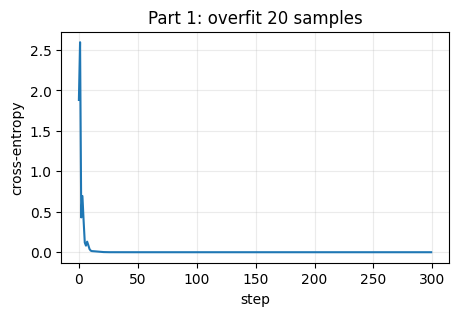

gradient norms: {'net.0.weight': 0.6493411660194397, 'net.0.bias': 0.2982858717441559, 'net.2.weight': 1.994356393814087, 'net.2.bias': 0.3963472843170166, 'net.4.weight': 2.1348347663879395, 'net.4.bias': 0.5349802374839783}


In [8]:
torch.manual_seed(7)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print("M-base parameters:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47879
probe = torch.randn(8, 54, device=device)
logits = model(probe)
print("probe shape -> logits shape:", tuple(probe.shape), "->", tuple(logits.shape))
assert logits.shape == (8, 7) and logits.dtype == torch.float32
model.eval()
with torch.no_grad():
    step0_loss = torch.nn.functional.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"step-0 validation cross-entropy={step0_loss:.4f}; ln(7)={np.log(7):.4f}")
print("activation std after Linear layers:", activation_stats(model, data["X_val"][:256]))
torch.manual_seed(11)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=0.02)
tiny_X, tiny_y = data["X_tr"][:20], data["y_tr"][:20]
tiny_curve = []
for _ in range(300):
    tiny_optimizer.zero_grad(set_to_none=True)
    tiny_loss = torch.nn.functional.cross_entropy(tiny_model(tiny_X), tiny_y)
    tiny_loss.backward()
    tiny_optimizer.step()
    tiny_curve.append(float(tiny_loss.detach().cpu()))
tiny_model.eval()
with torch.no_grad():
    tiny_pred = tiny_model(tiny_X).argmax(dim=1)
tiny_acc = (tiny_pred == tiny_y).float().mean().item()
print(f"20-sample overfit: loss {tiny_curve[0]:.4f} -> {tiny_curve[-1]:.6f}, accuracy={tiny_acc:.1%}")
assert tiny_curve[-1] < 0.01 and tiny_acc == 1.0
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(tiny_curve)
plt.xlabel("step"); plt.ylabel("cross-entropy"); plt.title("Part 1: overfit 20 samples")
plt.grid(alpha=0.25); plt.show()
gradient_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
gradient_model.zero_grad(set_to_none=True)
gradient_loss = torch.nn.functional.cross_entropy(gradient_model(data["X_val"][:64]), data["y_val"][:64])
gradient_loss.backward()
grad_norms = {name: float(parameter.grad.norm().item()) for name, parameter in gradient_model.named_parameters()}
print("gradient norms:", grad_norms)
assert all(parameter.grad is not None for parameter in gradient_model.parameters())
assert all(np.isfinite(value) and value > 0.0 for value in grad_norms.values())

**Nhận xét Part 1 (tự viết):** loss bước 0 đo được = ___, so với ln 7 = 1.946 vì sao ...; quá khớp 20 mẫu: ...

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [9]:
lr_candidates = [0.01, 0.03, 0.1]
lr_probe_results = []
for candidate in lr_candidates:
    probe_cfg = {**DEFAULT_CFG, "exp_id": f"lr-probe-{candidate:g}", "lr": candidate, "epochs": 3, "seed": 1}
    probe = run_experiment(probe_cfg, data)
    lr_probe_results.append(probe)
    print(f"lr={candidate:g} -> val_acc={probe['summary']['val_acc']:.4f}, val_macro_f1={probe['summary']['val_macro_f1']:.4f}")
best_lr_result = max(lr_probe_results, key=lambda result: result["summary"]["val_macro_f1"])
best_lr = float(best_lr_result["cfg"]["lr"])
print("selected learning rate by validation macro-F1:", best_lr)
cfg = {**DEFAULT_CFG, "lr": best_lr}
baseline_results = []
for seed in (1, 2, 3):
    exp_cfg = {**cfg, "seed": seed, "exp_id": f"base-s{seed}", "description": f"Baseline M-base, seed {seed}"}
    result = run_experiment(exp_cfg, data)
    baseline_results.append(result)
    exp_id = exp_cfg["exp_id"]
    save_result(result, os.path.join(OUT_DIR, "results"))
    plot_run(result, os.path.join(OUT_DIR, "figures", f"{exp_id}.png"))
    print(exp_id, result["summary"])
seed_f1 = np.array([r["summary"]["val_macro_f1"] for r in baseline_results])
seed_acc = np.array([r["summary"]["val_acc"] for r in baseline_results])
print(f"baseline val_macro_f1={seed_f1.mean():.4f} ± {seed_f1.std(ddof=1):.4f}; 2σ={2 * seed_f1.std(ddof=1):.4f}")
print(f"baseline val_acc={seed_acc.mean():.4f} ± {seed_acc.std(ddof=1):.4f}")

lr=0.01 -> val_acc=0.7908, val_macro_f1=0.6166
lr=0.03 -> val_acc=0.8251, val_macro_f1=0.6950
lr=0.1 -> val_acc=0.8389, val_macro_f1=0.7264
selected learning rate by validation macro-F1: 0.1
base-s1 {'step0_loss': 2.269061788393712, 'best_val_loss': 0.2290156836282063, 'best_epoch': 19, 'final_train_loss': 0.21361110473632813, 'final_val_loss': 0.23919273884150077, 'val_acc': 0.9078763127326965, 'val_macro_f1': 0.8547156048430543, 'time_per_epoch_s': 1.3469768176499997, 'peak_mem_MB': 161.005859375, 'diverged': False}
base-s2 {'step0_loss': 1.9781567018815485, 'best_val_loss': 0.23133777580573917, 'best_epoch': 16, 'final_train_loss': 0.2132419549560547, 'final_val_loss': 0.23800585973216878, 'val_acc': 0.9074782729148865, 'val_macro_f1': 0.8509017867242641, 'time_per_epoch_s': 1.3415938728499897, 'peak_mem_MB': 161.005859375, 'diverged': False}
base-s3 {'step0_loss': 1.9005399530688614, 'best_val_loss': 0.23247605960634452, 'best_epoch': 20, 'final_train_loss': 0.21004149841308595, 'f

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `drop-0.3` — chủ đề `dropout`

**Dự đoán trước:** Dropout 0.3 có thể giảm overfitting và thu hẹp khoảng cách
train/validation, nhưng train loss có thể cao hơn và tốc độ học chậm hơn.

### Thí nghiệm `arch-deep` — chủ đề `hparam`

**Dự đoán trước:** M-deep có thêm một lớp ẩn nên có thể học biểu diễn tốt hơn
và tăng validation macro-F1 nếu baseline còn underfit, nhưng thời gian chạy sẽ lâu hơn.

### Thí nghiệm `init-xavier` — chủ đề `init`

**Dự đoán trước:** Xavier có thể làm loss bước 0 ổn định hơn He, nhưng điểm
validation cuối chưa chắc cải thiện đáng kể.

In [10]:
experiment_specs = [
    ({"exp_id": "drop-0.3", "group": "dropout", "description": "M-base with dropout 0.3", "dropout": 0.3}, "dropout"),
    ({"exp_id": "arch-deep", "group": "hparam", "description": "M-deep architecture", "hidden": (256, 128, 64)}, "architecture"),
    ({"exp_id": "init-xavier", "group": "init", "description": "M-base with Xavier initialization", "init": "xavier"}, "initialization"),
]
part3_results = []
for changes, topic in experiment_specs:
    exp_cfg = {**cfg, **changes, "seed": 1}
    print(f"\nPrediction for {exp_cfg['exp_id']} ({topic}): {exp_cfg['description']}")
    result = run_experiment(exp_cfg, data)
    part3_results.append(result)
    exp_id = exp_cfg["exp_id"]
    save_result(result, os.path.join(OUT_DIR, "results"))
    plot_run(result, os.path.join(OUT_DIR, "figures", f"{exp_id}.png"))
    print(result["summary"])
baseline_reference = max(baseline_results, key=lambda r: r["summary"]["val_macro_f1"])
noise_2sigma = 2 * seed_f1.std(ddof=1)
for result in part3_results:
    delta = result["summary"]["val_macro_f1"] - baseline_reference["summary"]["val_macro_f1"]
    print(f"{result['cfg']['exp_id']}: Δ val_macro_f1={delta:+.4f}; vượt 2σ? {abs(delta) > noise_2sigma}")


Prediction for drop-0.3 (dropout): M-base with dropout 0.3
{'step0_loss': 2.269061788393712, 'best_val_loss': 0.3192252217408894, 'best_epoch': 20, 'final_train_loss': 0.31255743408203124, 'final_val_loss': 0.3192252217408894, 'val_acc': 0.8709364533424377, 'val_macro_f1': 0.7825720615342274, 'time_per_epoch_s': 1.414674867300016, 'peak_mem_MB': 161.005859375, 'diverged': False}

Prediction for arch-deep (architecture): M-deep architecture
{'step0_loss': 1.9099424319547234, 'best_val_loss': 0.20835250467449906, 'best_epoch': 17, 'final_train_loss': 0.1801269287109375, 'final_val_loss': 0.2104055765319852, 'val_acc': 0.9171058535575867, 'val_macro_f1': 0.867990668338523, 'time_per_epoch_s': 1.4595013187000176, 'peak_mem_MB': 161.0966796875, 'diverged': False}

Prediction for init-xavier (initialization): M-base with Xavier initialization
{'step0_loss': 2.0221761899351347, 'best_val_loss': 0.22387343527504855, 'best_epoch': 20, 'final_train_loss': 0.20218959533691405, 'final_val_loss': 

**Đối chiếu sau khi chạy:**

- `drop-0.3`: Dự đoán khớp một phần. Dropout giúp mô hình đạt
  `val_macro_f1 = 0.7826`, `val_acc = 0.8709`. Khoảng cách giữa train loss
  và validation loss cuối là khoảng `0.0067`, cho thấy hiện tượng overfitting
  được kiểm soát khá tốt. Chênh lệch macro-F1 so với baseline là `+0.0782`
  và vượt `2σ`, nên đây là cải thiện đáng chú ý.

- `arch-deep`: Dự đoán khớp. M-deep đạt `val_macro_f1 = 0.8679`,
  `val_acc = 0.9171`, tốt hơn baseline. Mô hình có thêm lớp ẩn nên có khả năng
  học biểu diễn phức tạp hơn. Chênh lệch macro-F1 là `+0.0133` và vượt `2σ`,
  vì vậy cải thiện này lớn hơn mức nhiễu giữa các seed.

- `init-xavier`: Dự đoán chỉ khớp ở loss bước 0. Xavier cho loss bước 0 là
  khoảng `2.0222`, nhưng macro-F1 cuối đạt `0.8539`, gần như không cải thiện
  so với baseline. Chênh lệch là `-0.0008` và không vượt `2σ`, nên chưa có
  bằng chứng Xavier tốt hơn He.

In [12]:
all_comparison_results = baseline_results + part3_results
plot_compare(all_comparison_results, "val_macro_f1", os.path.join(OUT_DIR, "figures", "compare_part3.png"), title="Baseline and Part 3 validation macro-F1")
plot_compare(all_comparison_results, "val_loss", os.path.join(OUT_DIR, "figures", "compare_part3_loss.png"), title="Baseline and Part 3 validation loss")
all_results = all_comparison_results
valid_results = [r for r in all_results if not r["summary"].get("diverged", False) and np.isfinite(r["summary"]["val_macro_f1"]) ]
result_final = max(valid_results, key=lambda r: r["summary"]["val_macro_f1"])
cfg_final = result_final["cfg"]
print(f"Selected final configuration by validation: {cfg_final['exp_id']} with val_macro_f1={result_final['summary']['val_macro_f1']:.4f}")

Selected final configuration by validation: arch-deep with val_macro_f1=0.8680


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [13]:
# Part 0–3 phải được chạy trước để có best_state của cấu hình được chọn bằng validation.
if "result_final" not in globals() or "cfg_final" not in globals():
    raise RuntimeError("Hãy chạy các ô Part 0–3 trước Part 4.")

# Baseline dùng seed có val macro-F1 tốt nhất; cấu hình nộp dùng kết quả được chọn chỉ bằng val.
baseline_result = max(baseline_results, key=lambda r: r["summary"]["val_macro_f1"])
baseline_cfg = baseline_result["cfg"]
final_pred_path = os.path.abspath(os.path.join(OUT_DIR, "predictions_eval.csv"))
baseline_pred_path = os.path.abspath(os.path.join(OUT_DIR, "predictions_baseline.csv"))
final_eval(cfg_final, result_final, data, final_pred_path)
final_eval(baseline_cfg, baseline_result, data, baseline_pred_path)

# Chạy script chấm từ thư mục gốc repo để kiểm tra đủ 116203 dòng và thứ tự row_id.
eval_env = os.environ.copy()
eval_env["PYTHONIOENCODING"] = "utf-8"
def score_predictions(pred_path, out_path):
    subprocess.run([
        sys.executable, os.path.join(REPO_ROOT, "scripts", "evaluate.py"),
        "--pred", pred_path, "--out", out_path,
    ], cwd=REPO_ROOT, env=eval_env, check=True)

final_eval_json = os.path.abspath(os.path.join(OUT_DIR, "eval_result.json"))
baseline_eval_json = os.path.abspath(os.path.join(OUT_DIR, "eval_baseline_result.json"))
score_predictions(final_pred_path, final_eval_json)
score_predictions(baseline_pred_path, baseline_eval_json)
with open(final_eval_json, encoding="utf-8") as f:
    final_eval_scores = json.load(f)
with open(baseline_eval_json, encoding="utf-8") as f:
    baseline_eval_scores = json.load(f)
print("Final configuration:", cfg_final["exp_id"])
print("Final eval:", {k: final_eval_scores.get(k) for k in ("accuracy", "macro_f1")})
print("Baseline eval:", {k: baseline_eval_scores.get(k) for k in ("accuracy", "macro_f1")})

n_eval = 116203
accuracy = 0.9167
macro_f1 = 0.8716   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9291  0.8962  0.9124
  1    56661     0.9181  0.9420  0.9299
  2     7151     0.8995  0.9348  0.9168
  3      549     0.8379  0.7723  0.8038
  4     1899     0.7704  0.7936  0.7818
  5     3473     0.8617  0.8071  0.8335
  6     4102     0.9278  0.9183  0.9231

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37969   4086     0    3    40    11   259
1   2555  53372   153    0   378   169    34
2      1    156  6685   51    22   236     0
3      0      0   105  424     0    20     0
4     27    331    20    0  1507    14     0
5      8    156   469   28     9  2803     0
6    305     30     0    0     0     0  3767

đã ghi /kaggle/working/K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork/submission_2A202602791/eval_result.json
n_eval = 116203
accuracy = 0.9077
macro_f1 = 0.8555   <- chỉ số chính

lớp  support  pr

In [14]:
# Phân tích lỗi chỉ để báo cáo; không dùng eval để đổi cấu hình đã chọn.
per_class = final_eval_scores["per_class"]
confusion = np.asarray(final_eval_scores["confusion_matrix"], dtype=int)
print("Per-class precision / recall / F1 / support")
for row in per_class:
    print("class {cls}: precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}, support={support}".format(**row))
print("Confusion matrix (rows=true, columns=pred):\n", confusion)
hardest = min(per_class, key=lambda row: row["f1"])
row_confusions = confusion[int(hardest["cls"])].copy()
row_confusions[int(hardest["cls"])] = 0
most_confused = int(row_confusions.argmax()) if row_confusions.sum() else None
print(f"Hardest class by F1: {hardest['cls']} (F1={hardest['f1']:.4f}, support={hardest['support']})")
if most_confused is not None:
    print(f"Most frequent confusion for class {hardest['cls']}: predicted as {most_confused} ({row_confusions[most_confused]} samples)")

Per-class precision / recall / F1 / support
class 0: precision=0.9291, recall=0.8962, f1=0.9124, support=42368
class 1: precision=0.9181, recall=0.9420, f1=0.9299, support=56661
class 2: precision=0.8995, recall=0.9348, f1=0.9168, support=7151
class 3: precision=0.8379, recall=0.7723, f1=0.8038, support=549
class 4: precision=0.7704, recall=0.7936, f1=0.7818, support=1899
class 5: precision=0.8617, recall=0.8071, f1=0.8335, support=3473
class 6: precision=0.9278, recall=0.9183, f1=0.9231, support=4102
Confusion matrix (rows=true, columns=pred):
 [[37969  4086     0     3    40    11   259]
 [ 2555 53372   153     0   378   169    34]
 [    1   156  6685    51    22   236     0]
 [    0     0   105   424     0    20     0]
 [   27   331    20     0  1507    14     0]
 [    8   156   469    28     9  2803     0]
 [  305    30     0     0     0     0  3767]]
Hardest class by F1: 4 (F1=0.7818, support=1899)
Most frequent confusion for class 4: predicted as 1 (331 samples)


**Phân tích lỗi:** bảng theo lớp và ma trận nhầm lẫn ở ô trên được lấy trực tiếp từ `eval_result.json`. Lớp khó nhất là lớp có F1 thấp nhất; nhận xét cần đối chiếu thêm `support` và nhãn mà lớp đó bị nhầm nhiều nhất. Điểm eval chỉ dùng để báo cáo sau khi đã chốt cấu hình bằng validation.

In [16]:
results = load_results(os.path.join(OUT_DIR, "results"))
eval_by_exp = {
    baseline_cfg["exp_id"]: baseline_eval_scores,
    cfg_final["exp_id"]: final_eval_scores,
}
notes_by_exp = {
    baseline_cfg["exp_id"]: "Baseline; điểm eval dùng để đối chiếu.",
    cfg_final["exp_id"]: "Cấu hình cuối được chọn bằng val; đây là kết quả nộp.",
}
rows = [to_row(r, eval_by_exp.get(r["cfg"].get("exp_id")), notes_by_exp.get(r["cfg"].get("exp_id"))) for r in results]
xlsx_path = os.path.join(OUT_DIR, "experiments.xlsx")
write_xlsx(rows, os.path.join(REPO_ROOT, "templates", "experiment_table_template.xlsx"), xlsx_path)
# Giữ các công thức của mẫu, đồng thời ghi rõ các seed baseline và nhận xét theo nhóm.
from openpyxl import load_workbook
workbook = load_workbook(xlsx_path)
seeds_sheet = workbook["Seeds"]
for row_number, baseline in enumerate(baseline_results[:5], start=2):
    seeds_sheet.cell(row_number, 1).value = baseline["cfg"]["exp_id"]
summary_notes = {
    "baseline": f"{len(baseline_results)} seed; val macro-F1 trung bình {seed_f1.mean():.4f} ± {seed_f1.std(ddof=1):.4f}.",
    "dropout": "drop-0.3 dùng cùng seed và số epoch; kiểm tra regularization qua khoảng cách train–val.",
    "hparam": "arch-deep thay đổi độ sâu; chỉ kết luận khi chênh lệch val vượt 2σ baseline.",
    "init": "init-xavier chỉ thay đổi khởi tạo; đối chiếu loss bước 0 và macro-F1 trên val.",
    "final": f"Chọn {cfg_final['exp_id']} theo val macro-F1; eval không tham gia chọn.",
}
summary_sheet = workbook["Summary"]
for row_number in range(2, summary_sheet.max_row + 1):
    group_name = summary_sheet.cell(row_number, 1).value
    if group_name in summary_notes:
        summary_sheet.cell(row_number, 8).value = summary_notes[group_name]
workbook.save(xlsx_path)
print("Wrote experiment table:", xlsx_path)

Wrote experiment table: /kaggle/working/K4-Track4-Day1-TongTranTienDung-02791-Neuralnetwork/submission_2A202602791/experiments.xlsx
